In [1]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import json

from matplotlib import cm 
colors = cm.Reds(np.linspace(0.4, 0.9, 10))  # Gradient from light to dark red

import sys
sys.path.append('../../')

from src.viz import (
    plot_transition_matrix,
    plot_distribution,
    plot_implied_timescales,
)
from src.markov_analysis import *
from src.preprocessing import compute_speed_turning_angles

#sns.set(style="white", context="notebook")

def extract_eigen_values(dict_in):
    # Extract spectrum per tau
    spectrum_tau = dict_in["spectrum_tau"]  # keys are strings, e.g. "1", "2", ...
    # Convert tau keys to integers and sort
    tau_list = sorted(map(int, spectrum_tau.keys()))
    # Initialize list of lists: eigval_curves[i][j] = i-th eigval at j-th tau
    eigval_curves = [[] for _ in range(10)]
    for tau in tau_list:
        eigvals = spectrum_tau[str(tau)]
        for i in range(min(10, len(eigvals))):
            eigval_curves[i].append(eigvals[i])
    return eigval_curves,tau_list

In [3]:

# Load the saved JSON
with open("../../data/choano/processed/markov_summary_fed_track.json", "r") as f:
    data_fed = json.load(f)
eigval_curves_fed,tau_list_fed = extract_eigen_values(data_fed)

with open("../../data/choano/processed/markov_summary_starve_track.json", "r") as f:
    data_starve = json.load(f)
eigval_curves_starve,tau_list_starve = extract_eigen_values(data_starve)

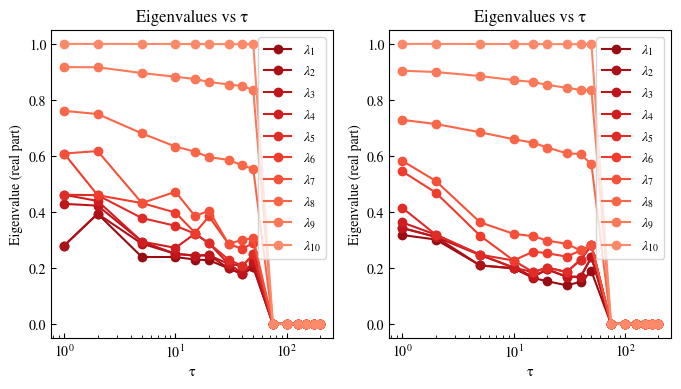

In [4]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
for i, eigs in enumerate(eigval_curves_starve):
    ax[0].plot(tau_list_starve, eigs,marker='o', label=r"$\lambda_{"+str(i+1)+"}$",color=colors[9-i])
for i, eigs in enumerate(eigval_curves_fed):
    ax[1].plot(tau_list_fed, eigs,marker='o', label=r"$\lambda_{"+str(i+1)+"}$",color=colors[9-i])

ax[0].set_xlabel("τ")
ax[0].set_ylabel("Eigenvalue (real part)")
ax[0].set_title("Eigenvalues vs τ")
ax[0].set_xscale('log')
ax[0].legend()

ax[1].set_xlabel("τ")
ax[1].set_ylabel("Eigenvalue (real part)")
ax[1].set_title("Eigenvalues vs τ")
ax[1].set_xscale('log')
ax[1].legend()

In [6]:
# Paths to data from embed_and_cluster.py
with open("../../data/choano/processed/embedding_fed_track.pkl", "rb") as f:
        emb_fed = pickle.load(f)
with open("../../data/choano/processed/embedding_starve_track.pkl", "rb") as f:
        emb_starve = pickle.load(f)
#with open("../../data/copepods/processed/markov.pkl", "rb") as f:
#        mkv = pickle.load(f)


print(f"Labels fed track shape: {emb_fed.labels}")
print(f"Embedding fed track shape: {emb_fed.embedding_matrix.shape}")

labels_counting_fed = dict(Counter(emb_fed.labels))

print(f"Labels fed track shape: {emb_starve.labels}")
print(f"Embedding fed track shape: {emb_starve.embedding_matrix.shape}")

labels_counting_fed = dict(Counter(emb_starve.labels))


Labels fed track shape: [90 90 90 ... 90 90 90]
Embedding fed track shape: (270, 71, 90)
Labels fed track shape: [15 15 15 ... 15 15 15]
Embedding fed track shape: (336, 71, 90)


In [7]:
mkv_starve = Markov(emb_starve,tau=10)
mkv_fed = Markov(emb_fed,tau=10)

In [8]:
with open("../../data/choano/processed/embedding_starve_track.pkl", "wb") as f:
        pickle.dump(emb_starve,f,protocol=pickle.HIGHEST_PROTOCOL)

with open("../../data/choano/processed/embedding_fed_track.pkl", "wb") as f:
        pickle.dump(emb_fed,f,protocol=pickle.HIGHEST_PROTOCOL)